# Visión Artificial
## Práctica 2: Detección de fronteras de color con método de Gradiente y Laplaciano

---

### Datos
|  | Detalle |
| :--- | :--- |
| **📚 Materia** | Visión Artificial |
| **🎓 Programa** | Maestría en Ciencia de Datos |
| **📅 Periodo** | 3.° Semestre (Agosto-Diciembre 2026) |
| **👨‍💻 Autor** | Abraham Eduardo Ordorica Islas |
| **🏷️ Perfil Asignado** | Perfil 2 |
| **📝 Fecha** | 31 de Agosto de 2026 |


## 1. Marco teórico

### 1.1 Espacio de Color LAB y Segmentación Cromática de Azul

El espacio de color **LAB ($L^*a^*b^*$)** es un modelo tridimensional diseñado conforme a la teoría de colores, caracterizado por su uniformidad perceptual y el desacoplamiento total de la luminancia respecto a la cromaticidad.
* **Canal $L^*$ (Luminancia):** Representa la claridad perceptual con un rango teórico de $0$ (negro absoluto) a $100$ (blanco difuso). Para representaciones de 8 bits (`uint8`) en OpenCV, se cuantifica en el intervalo $[0, 255]$.
* **Canal $a^*$ (Eje Verde-Rojo):** Modela la oposición cromática entre el verde (valores negativos) y el rojo (valores positivos). En escala de 8 bits (`uint8`), el verde puro se posiciona en $0$, el origen neutro se posiciona en $128$ y el rojo puro en $255$.
* **Canal $b^*$ (Eje Azul-Amarillo):** Modela la oposición cromática entre el azul (valores negativos) y el rojo (valores positivos). En escala de 8 bits (`uint8`), el azul puro se posiciona en $0$, el origen neutro se posiciona en $128$ y el amarillo puro en $255$. por ende, las tonalidades azules se concentran fundamentalmente en la parte inferior del eje:


| Espacio de Color | Canal de Luminancia | Canales Cromáticos |
| :---: | :---: | :---: |
| **LAB** | $L^*$ ($0 \leftrightarrow 255$) | $a^*$ (Verde $\leftrightarrow$ Rojo)<br>$b^*$ (Azul $\leftrightarrow$ Amarillo) |

> ⚠️ **Ventaja del desacoplamiento en LAB:**  
> Al evaluar únicamente el canal $b^*$, la segmentación de tonos azules se vuelve invariante respecto a cambios de iluminación y sombras presentes en el canal $L^*$, permitiendo aislar la región cromática.

### 1.2 Detección de Bordes y Fronteras Cromáticas 

Un borde en una imagen es una zona donde el color cambia de manera drástica (por ejemplo, pasar de negro a blanco). La extracción de fronteras espaciales sobre regiones cromáticamente segmentadas permite aislar el contorno geométrico de los objetos de interés. 
## 1. **El método del Gradiente:** 
El método del gradiente es una técnica de procesamiento de imágenes que encuentra los bordes calculando el cambio rápido en el brillo o intensidad entre los píxeles adyacentes. utiliza herramientas matemáticas llamadas derivadas para medir qué tan rápido y en qué dirección ocurre ese cambio. El método del gradiente arroja 2 métricas:
* **Magnitud:** Mide la fuerza del cambio de intensidad. Un valor alto significa que hay un borde fuerte y claro. Un valor bajo indica una zona uniforme.
* **Dirección:** Indica el ángulo hacia donde ocurre el cambio más rápido. Esta dirección siempre es perpendicular (en un ángulo de 90 grados) al borde detectado.

Para aplicar este método, se utilizan pequeñas matrices de números llamadas filtros u operadores. Los más populares son:
* **Filtro Sobel:** Es el más usado. Utiliza dos matrices de 3x3 píxeles para calcular los cambios horizontales y verticales.
* **Filtro Prewitt:** Funciona de forma muy parecida a Sobel, pero con valores numéricos ligeramente distintos en su matriz.
* **Filtro Roberts:** Usa matrices más pequeñas de 2x2. Es más rápido, pero más sensible al ruido de la imagen.

Para fines de estra práctica se usará un **filtro Sobel**. Altamente utilizado en visualización artificial para la **detección de bordes** en imágenes en escala de grises. Su objetivo es identificar las zonas donde hay un cambio brusco de brillo. El filtro calcula de forma independiente las variaciones de brillo en el eje horizontal ($X$) y vertical ($Y$) deslizando dos matrices (**kernels**) de $3 \times 3$ sobre la imagen original ($A$):

*   **Gradiente Horizontal ($G_x$):** Resalta bordes verticales mediante derivadas de izquierda a derecha.
*   **Gradiente Vertical ($G_y$):** Resalta bordes horizontales mediante derivadas de arriba a abajo.

$$G_x = \begin{bmatrix} -1 & 0 & +1 \\ -2 & 0 & +2 \\ -1 & 0 & +1 \end{bmatrix} * A \quad \text{y} \quad G_y = \begin{bmatrix} -1 & -2 & -1 \\ 0 & 0 & 0 \\ +1 & +2 & +1 \end{bmatrix} * A$$

Tras calcular $G_x$ y $G_y$ píxel a píxel, se procesa la información mediante dos ecuaciones:
* **A. Magnitud del Borde ($|G|$):** Determina la **fuerza o contraste** del borde aplicando el Teorema de Pitágoras. Elevar al cuadrado elimina los signos negativos (la dirección de la luz) y magnifica las diferencias de brillo.
$\vert{}G\vert{} = \sqrt{G_x^2 + G_y^2}$
* **B. Dirección del Gradiente ($\theta$):** Determina el **ángulo del cambio**. Apunta siempre de forma **perpendicular al borde** (en dirección al máximo brillo). Se usa `atan2` para conservar el signo y mapear los $360^\circ$ completos ($[-\pi, \pi]$ radianes).
$\theta = \operatorname{atan2}(G_y, G_x)$.

## 2. **El método del Laplaciano:** 
El método laplaciano es similar al método del gradiente, pero este método usa la derivada de  **segundo orden** utilizado en procesamiento de imágenes para la **detección de bordes** y el realce de detalles finos. A diferencia de Sobel, es un filtro **isotrópico**, lo que significa que detecta bordes en cualquier dirección (horizontal, vertical y diagonal) al mismo tiempo usando una sola matriz. Mientras que el filtro sobel busca la primera derivada (la velocidad del cambio de brillo), el Laplaciano calcula la **segunda derivada** (la aceleración del cambio). Matemáticamente es la suma de las segundas derivadas parciales en los ejes $X$ e $Y$:

$$\nabla^2 A = \frac{\partial^2 A}{\partial x^2} + \frac{\partial^2 A}{\partial y^2}$$

Para aproximar este cálculo píxel a píxel sobre una imagen ($A$), se utiliza una matriz de convolución de $3 \times 3$. Existen dos variantes clásicas de su arquitectura:



> 💡 **Nota de signo:** La suma de todos los elementos del kernel debe ser **0**. Esto garantiza que en zonas con brillo uniforme (donde no hay bordes), el resultado de la convolución sea exactamente cero. Los signos pueden invertirse (centro positivo y extremos negativos) dependiendo de la librería de programación.

Sus características son: 
* **Cruce por cero:** El Laplaciano calcula la aceleración del cambio de brillo. Un borde se detecta exactamente cuando el valor de la segunda derivada cruza el valor de cero, pasando de un pico positivo a uno negativo (Ver figura).
* **Omnidireccional:** No necesita calcular los bordes horizontales y verticales por separado. Detecta bordes en todas las direcciones al mismo tiempo.

<center>
<img src="https://docs.gimp.org/es/images/filters/edge-detect/gradient-calculation-fig.png" alt="Detección de bordes" width="500"/>
</center>

3. **El método Laplaciano del Gaussiano (LoG):** El Laplaciano es extremadamente sensible al ruido de la imagen. Cualquier imperfección o pixel suelto puede ser interpretado erróneamente como un borde. Para solucionar esto, casi siempre se aplica un filtro previo: Primero se aplica un filtro Gaussiano para suavizar la imagen y borrar el ruido. Luego, se aplica el Laplaciano para detectar los bordes reales.

   **Filtros o máscaras comunes:** Para aplicar este método se usan matrices (kernels) donde el centro tiene un valor alto (positivo o negativo) y los píxeles de alrededor balancean ese valor a cero. 
*   **Kernel Estándar (4-vecinos):** Considera solo los cambios arriba, abajo, izquierda y derecha.
*   **Kernel Extendido (8-vecinos):** Incluye las diagonales para una detección más suave y completa.

$$\text{Kernel (4-vecinos)} = \begin{bmatrix} 0 & 1 & 0 \\ 1 & -4 & 1 \\ 0 & 1 & 0 \end{bmatrix} \quad \text{o} \quad \text{Kernel (8-vecinos)} = \begin{bmatrix} 1 & 1 & 1 \\ 1 & -8 & 1 \\ 1 & 1 & 1 \end{bmatrix}$$


### 1.2.1 Diferencias clave y características:
* **El cruce por cero:**  En el punto exacto donde se encuentra el centro de un borde, la segunda derivada cambia bruscamente de signo (pasa de un pico positivo a uno negativo). El algoritmo detecta el borde buscando este **cruce por cero**, lo que genera líneas de contorno **mucho más finas** que las de Sobel.
* **Sensibilidad al ruido:** Al ser una segunda derivada, el Laplaciano amplifica drásticamente cualquier imperfección, "grano" o ruido en la imagen. Por ello, casi nunca se usa solo; se suele aplicar un suavizado Gaussiano previo. Esta combinación se conoce formalmente como el filtro **LoG (Laplacian of Gaussian)**.

## 2. 🛠️ Practical demonstration


### 2.1 ⚙️  Environment Setup and Configuration

This cell initializes all dependencies, constants, and infrastructure required to run the notebook reproducibly.

### Libraries
| Library | Purpose |
|---|---|
| `os`, `pathlib` | File system operations and cross-platform path handling |
| `logging` | Structured logging to console and persistent `.txt` files |
| `datetime` | Timestamped log filenames and session tracking |
| `traceback` | Detailed error reporting inside `try/except` blocks |
| `cv2` (OpenCV) | Image I/O, color space conversion, and spatial filtering |
| `numpy` | Array operations over image matrices |
| `pandas` | Tabular export of numerical results (CSV) |
| `matplotlib` | Visualization of processed images and comparison panels |

### Global STRAPS
| Flag | Default | Effect |
|---|---|---|
| `DEBUG` | `True` | Enables verbose debug-level output across all functions |
| `SAVE_LOGS` | `True` | Persists execution logs to a `.txt` file in the output directory |
| `SAVE_IMAGES` | `True` | Exports generated plots as `.png` files to `output_dir` |
| `CLEAN_LOGS` | `True` | Deletes previous log files matching the script prefix before each run |

### Fixed configurations
| Constant | Value | Description |
|---|---|---|
| `SCRIPT_PREFIX` | `Perfil2_Practica2_DeteccionBordes` | Naming convention prefix for all output artifacts |
| `SIGMA` | `[0.2, 0.7, 1.5, 3.0, 5.5]` | Gaussian standard deviation values used for LoG iterations |
| `EXTENSIONS` | `*.png, *.jpg, *.jpeg, *.bmp, *.tif` | Allowed image file formats for dataset loading |
| `COLOR_SPACE` | `LAB` | Target color space for all processing pipelines |



In [6]:
import os
import logging as log
import datetime as date
import traceback as trace
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DEBUG = True          # Enables verbose debug output across functions
SAVE_LOGS = True       # Controls file persistence for execution logs
SAVE_IMAGES = True     # Enables exporting generated plots to output_dir
CLEAN_LOGS = True     # Erases previous log files matching script prefix

DATE_STR = date.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
SCRIPT_PREFIX = "Perfil2_Practica2_DeteccionBordes"
LOG_NAME = f"{SCRIPT_PREFIX}__{DATE_STR}.txt"
COMPUTER_NAME = os.environ.get("COMPUTERNAME", "DEFAULT_PC")
SIGMA = [0.2,0.7,1.5,3.0,5.5]

# Define machine name and directory paths
if COMPUTER_NAME == "PC_ABRAHAM":
    BASE_DIR = Path("D:/Abraham/MyRepos/Maestria/05_Semestres/3er_Semestre/Vision_artificial")
else:
    BASE_DIR = Path("D:/Personal/Maestria/05_Semestres/3er_Semestre/Vision_artificial")
IMAGE_DIR = BASE_DIR / "Sesion_1/Samples"
output_dir = BASE_DIR / "Scripts/Output/Script2"
output_dir.mkdir(parents=True, exist_ok=True)

# Remove handler to allow clean previous logs
for handler in log.root.handlers[:]:
    handler.close()
    log.root.removeHandler(handler)

# This part deletes all previous logs if CLEAN_LOGS is set to True
if CLEAN_LOGS and output_dir.exists():
    pattern = f"{SCRIPT_PREFIX}__*.txt"
    old_logs = sorted(list(output_dir.glob(pattern)))
    if old_logs:
        print(f"\n🧹 'CLEAN_LOGS' active. Found {len(old_logs)} previous log(s).")
        for old_log in old_logs:
            try:
                old_log.unlink()
                print(f"🗑️ Deleted: {old_log.name}")
            except Exception as e:
                print(f"⚠️ Could not delete {old_log.name}: {e}")

# Logger setup, according to log naming convention
handlers = [log.StreamHandler()]
if SAVE_LOGS:
    log_file_path = str(output_dir / LOG_NAME)
    handlers.append(log.FileHandler(log_file_path, encoding="utf-8"))

log.basicConfig(
    level=log.DEBUG if DEBUG else log.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=handlers
)

logger = log.getLogger()
logger.info("=" * 80)
logger.info("🚀 STARTING PRACTICE NO. 2: Blue Color Boundary and Edge Detection")
logger.info("=" * 80 + "\n")
if DEBUG:
    logger.info(f"💻 Machine: {COMPUTER_NAME} | Date: {DATE_STR}")
    logger.info(f"📁 Input Directory: {IMAGE_DIR}")
    logger.info(f"📁 Output Directory: {output_dir}")

# Experiment Grid Configurations
EXTENSIONS = ("*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif")
COLOR_SPACE = "LAB"

logger.info(f"📱 Allowed image extensions: {EXTENSIONS}")
logger.info(f"🎨 Target Color Space: {COLOR_SPACE}")


2026-09-09 22:21:23,349 - INFO - ================================================================================
2026-09-09 22:21:23,351 - INFO - 🚀 STARTING PRACTICE NO. 2: Blue Color Boundary and Edge Detection
2026-09-09 22:21:23,352 - INFO - ================================================================================

2026-09-09 22:21:23,352 - INFO - 💻 Machine: PC_ABRAHAM | Date: 2026-09-09_22-21-23
2026-09-09 22:21:23,355 - INFO - 📁 Input Directory: D:\Abraham\MyRepos\Maestria\05_Semestres\3er_Semestre\Vision_artificial\Sesion_1\Samples
2026-09-09 22:21:23,355 - INFO - 📁 Output Directory: D:\Abraham\MyRepos\Maestria\05_Semestres\3er_Semestre\Vision_artificial\Scripts\Output\Script2
2026-09-09 22:21:23,357 - INFO - 📱 Allowed image extensions: ('*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tif')
2026-09-09 22:21:23,359 - INFO - 🎨 Target Color Space: LAB



🧹 'CLEAN_LOGS' active. Found 1 previous log(s).
🗑️ Deleted: Perfil2_Practica2_DeteccionBordes__2026-09-09_21-55-06.txt


## 2.2 Data Loading — Directory Scan, Decode, and Metadata

This section scans for images on path speciffication, converts them to RGB for visualization, and assembles a dataset list with basic metadata.

#### Function: `load_images(folder_path, extensions=EXTENSIONS)`
- Purpose: scan `folder_path` for files matching allowed extensions and load them into memory.
  - Uses `Path.glob` for each pattern in `extensions`, plus its UPPERCASE variant (handles case-insensitive extensions on case-sensitive FS).
  - Deduplicates with `set()` and sorts the final list for deterministic order.
  - Reads each file with `cv2.imread` (BGR), converts to `RGB` via `cv2.cvtColor` for plotting with Matplotlib.
- Return (list of dict):
  - One entry per successfully decoded image:
    ```
    {
      "filename": <str>,       # e.g., "photo.jpg"
      "rgb": <np.ndarray>,     # H×W×3, dtype=uint8, RGB
      "height": <int>,         # H
      "width": <int>,          # W
      "channels": <int>        # 3
    }
    ```

#### Function: `rgb_to_lab(rgb_image)`
- Purpose: Converts an in-memory `RGB` image to `LAB` (`cv2.COLOR_RGB2LAB`), this allows to work on isolated b* channel.
- Return: 3 uint-8 arrays, one for each channel Luminance (L), a* channel, b* channel

In [7]:
def load_images(folder_path: Path, extensions: list[str] = EXTENSIONS) -> list:
    """
    Scans over a specified PATH and loads all images found with a valid EXTENSION.
    Then, returns a dictionary with all the information for that image (metadata).
    """
    images_data = []
    try:
        logger.info("------- SECTION 1: Data Load -------")
        logger.info(f"⌛ Scanning directory: {folder_path}")
        files = []
        for ext in extensions:
            files.extend(list(folder_path.glob(ext)))
            files.extend(list(folder_path.glob(ext.upper())))

        files = sorted(list(set(files)))

        if not files:
            logger.warning(f"⚠️ No images detected in {folder_path} for extensions {extensions}")
            return images_data
        else:
            logger.info(f"🔍 Total image files detected: {len(files)}")

        for file_path in files:
            bgr_img = cv2.imread(str(file_path))
            if bgr_img is not None:
                rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
                images_data.append({
                    "filename": file_path.name,
                    "rgb": rgb_img,
                    "height": rgb_img.shape[0],
                    "width": rgb_img.shape[1],
                    "channels": rgb_img.shape[2]
                })
                if DEBUG:
                    logger.debug(f"  📄 Loaded: {file_path.name} | Dimensions: {rgb_img.shape}")
            else:
                logger.error(f"❌ Failed to decode image file: {file_path.name}")

        logger.info(f"✅ Successfully loaded {len(images_data)} of {len(files)} images.")
        logger.info("---- SECTION 1 (END): Data Load ----\n\n")
    except Exception as e:
        logger.error(f"❌ Error inside 'load_images' function: {trace.format_exc()}\n")

    return images_data

def rgb_to_lab(rgb_image: np.ndarray) -> np.ndarray:
    """Converts an RGB image array to LAB space."""
    return cv2.cvtColor(rgb_image, cv2.COLOR_RGB2LAB)

# Call the 'load_images' function and populate the dataset
dataset = load_images(IMAGE_DIR)

2026-09-09 22:21:23,378 - INFO - ------- SECTION 1: Data Load -------
2026-09-09 22:21:23,380 - INFO - ⌛ Scanning directory: D:\Abraham\MyRepos\Maestria\05_Semestres\3er_Semestre\Vision_artificial\Sesion_1\Samples
2026-09-09 22:21:23,383 - INFO - 🔍 Total image files detected: 5
2026-09-09 22:21:23,616 - DEBUG -   📄 Loaded: Alexa.jpg | Dimensions: (6000, 4000, 3)
2026-09-09 22:21:23,734 - DEBUG -   📄 Loaded: Buenos_Aires.jpg | Dimensions: (2295, 4080, 3)
2026-09-09 22:21:23,866 - DEBUG -   📄 Loaded: Piano_Man.jpg | Dimensions: (4000, 6000, 3)
2026-09-09 22:21:24,146 - DEBUG -   📄 Loaded: Tatto_Studio.jpg | Dimensions: (6000, 4000, 3)
2026-09-09 22:21:24,404 - DEBUG -   📄 Loaded: Ushuaia.jpg | Dimensions: (6000, 4000, 3)
2026-09-09 22:21:24,404 - INFO - ✅ Successfully loaded 5 of 5 images.
2026-09-09 22:21:24,405 - INFO - ---- SECTION 1 (END): Data Load ----




## 2.3 Blue-Channel Border and Edge Detection.
Creates a grayscale view where "more blue" looks brighter, then finds boundaries around those blue regions using two complementary edge finders.

### `apply_blue_gradient(lab_image, ksize=3)`
- **Input:** One image already converted to LAB `lab_image` (`np.ndarray`); `ksize` (`int`) controls how "wide" the local comparison is.
- **Output (tuple):**
  - `blue_scalar_map` (`np.ndarray`, uint8) — A grayscale view where brighter means "deeper blue."
  - `magnitude_clipped` (`np.ndarray`, uint8) — An edge-strength image (brighter = stronger boundary).
  - `grad_x` (`np.ndarray`, float64) — Auxiliary map describing how the signal changes (X-Axis).
  - `grad_y` (`np.ndarray`, float64) — Auxiliary map describing how the signal changes (Y-Axis).
  - `orientation_deg` (`np.ndarray`, float64) — An angle map in degrees `(0, 360)` indicating the direction of each boundary.

### `apply_blue_laplacian(lab_image, ksize=3, use_log=True, sigma=1.0)`
- **Input:** One LAB image `lab_image` (`np.ndarray`); `ksize` (`int`) controls edge sharpness; `use_log` (`bool`) toggles a prior smoothing step; `sigma` (`float`) controls how strong that smoothing is.
- **Output (tuple):**
  - `blue_scalar_map` (`np.ndarray`, uint8) — The same grayscale "blue intensity" view used for analysis.
  - `laplacian_64f` (`np.ndarray`, float64) — A signed response (useful for analysis/zero-crossings).
  - `laplacian_abs` (`np.ndarray`, uint8) — An edge-strength image (brighter = stronger boundary), ready to visualize or threshold.
  - `pre_smoothed` (`np.ndarray`, uint8) — The exact version of the image that was analyzed (with or without smoothing applied).

### `process_border_detection_(dataset_list, ksize=3)`
- **Input:** `dataset_list` (`list[dict]`) — a list of items, each with `filename` and an RGB image; `ksize` (`int`) shared by all runs.
- **What it does:** For each image, converts to LAB, runs the gradient method, runs the direct Laplacian, and then repeats Laplacian with several smoothing levels (the `SIGMA` values configured globally). It logs progress and stores results.
- **Output (tuple of two lists):**
  - `borders_by_gradient` (`list[dict]`) — Gradient results per image (blue view, edge strength, direction info).
  - `borders_by_laplacian` (`list[dict]`) — Laplacian results per image, labeled by method (`Laplacian_direct` vs. `LoG_sigma_X`), including both the signed response and the visual edge-strength image.


In [8]:
def apply_blue_gradient(lab_image: np.ndarray, ksize: int = 3) -> tuple:
    """Applies spatial gradient method (1st derivative) over the blue chromatic component in LAB.

        TODO: Add this description in Markdown
    Parameters:
    -----------
    lab_image : np.ndarray
        Image in LAB color space (uint8).
    ksize : int
        Sobel kernel size (default: 3).

    Returns:
    --------
    tuple : (blue_scalar_map, magnitude_clipped, grad_x, grad_y, orientation_deg)
        - blue_scalar_map: Inverted b* channel where higher intensity = stronger blue.
        - magnitude_clipped: Gradient magnitude normalized to uint8 [0, 255].
        - grad_x: Horizontal derivative in 64-bit float (CV_64F).
        - grad_y: Vertical derivative in 64-bit float (CV_64F).
        - orientation_deg: Gradient orientation angle in degrees [0, 360).
    """
    _, _, b_channel = cv2.split(lab_image)              # Split channels and isolate b* (Yellow-Blue axis)
    blue_scalar_map = cv2.bitwise_not(b_channel)        # Invert b* channel with not bitwise, so blue tones map to high intensity values

    # Apply gradient method in x and y axis using sobel filter in 64-bit float
    grad_x = cv2.Sobel(blue_scalar_map, cv2.CV_64F, 1, 0, ksize=ksize)
    grad_y = cv2.Sobel(blue_scalar_map, cv2.CV_64F, 0, 1, ksize=ksize)

    # Calculate gradient magnidute based on pythagoras theorem: ||∇I|| = sqrt(Gx^2 + Gy^2)
    magnitude = np.sqrt(grad_x**2 + grad_y**2)
    magnitude_clipped = np.clip(magnitude, 0, 255).astype(np.uint8)

    # Calculate gradient orientation using trigonometry: θ = arctan2(Gy, Gx)
    orientation_rad = np.arctan2(grad_y, grad_x)
    orientation_deg = np.degrees(orientation_rad) % 360.0

    return blue_scalar_map, magnitude_clipped, grad_x, grad_y, orientation_deg

def apply_blue_laplacian(lab_image: np.ndarray, ksize: int = 3, use_log: bool = True, sigma: float = 1.0) -> tuple:
    """
    Applies Laplacian (2nd derivative) over the blue chromatic component in LAB.
    Optional arguments allows to use Laplacian-of-Gaussian (LoG) by pre-smoothing with a Gaussian.
    
    TODO: Use markdown to document this

    Returns
    -------
    tuple : (blue_scalar_map, laplacian_abs, laplacian_64f, pre_smoothed)
        - blue_scalar_map: Inverted b* channel where higher intensity = stronger blue.
        - laplacian_abs: |Laplacian| normalized to uint8 [0, 255] for visualization.
        - laplacian_64f: Raw Laplacian response in 64-bit float (CV_64F).
        - pre_smoothed: Image used as input to Laplacian (after optional Gaussian blur).
    """
    
    _, _, b_channel = cv2.split(lab_image)                  # Split channels and isolate b* (Yellow-Blue axis)
    blue_scalar_map = cv2.bitwise_not(b_channel)            # Invert b* channel with not bitwise, so blue tones map to high intensity values
    pre_smoothed=blue_scalar_map
    
    if use_log:
        pre_smoothed = cv2.GaussianBlur(blue_scalar_map, (0, 0), sigmaX=sigma, sigmaY=sigma)        
    else:
        pass
    # Apply laplacian method to presmothed map or blue scalar map
    laplacian_64f = cv2.Laplacian(pre_smoothed, ddepth=cv2.CV_64F, ksize=ksize)
    laplacian_abs = cv2.convertScaleAbs(laplacian_64f)      # Apply absolute value to get the border

    return blue_scalar_map, laplacian_64f, laplacian_abs, pre_smoothed

def process_border_detection_(dataset_list: list, ksize: int = 3) -> list:
    """Processes all images in the dataset, applying gradient method over LAB blue channel."""

    # Declare empty listo to append results
    borders_by_gradient = []
    borders_by_laplacian = []
    if not dataset_list:
        logger.warning("⚠️ No images to process in dataset.")
        return borders_by_gradient

    logger.info("------- SECTION 2: Gradient method over blue channel -------")
    try:
        for idx, item in enumerate(dataset_list, 1):
            filename = item["filename"]
            rgb_img = item["rgb"]

            logger.info(f"\n🖼️ Working on image: '{filename}' [{idx}/{len(dataset_list)}] ")
            logger.info(f"  ⌛ Appliying gradient method...")

            # Convert current image to LAB
            lab_img = rgb_to_lab(rgb_img)
            # Apply gradient over blue channel             
            blue_map, grad_mag, gx, gy, theta = apply_blue_gradient(lab_img, ksize=ksize)
            # Save metadata 
            borders_by_gradient.append({
                "filename": filename,
                "blue_map": blue_map,
                "grad_magnitude": grad_mag,
                "grad_x": gx,
                "grad_y": gy,
                "orientation": theta,
            })
            logger.info(f"  ✅ Gradient method applied successfully.")

            logger.info(f"  ⌛ Appliying direct laplacian method (not smoothing)...")
            blue_map, lap_value, lap_abs, pre_smooth = apply_blue_laplacian(
                lab_img, 
                ksize=ksize, 
                use_log=False, 
                sigma=1.0)
            # Save metadata
            borders_by_laplacian.append({
                "filename": filename,
                "method": "Laplacian_direct",
                "sigma": None,
                "blue_map": blue_map,
                "laplacian_value": lap_value,
                "laplacian_magnitude": lap_abs,
                "pre-smoothed": pre_smooth,
            })
            logger.info(f"  ✅ Direct laplacian method applied successfully.")                        
            for sigma in SIGMA:
                logger.info(f"  ⌛ Appliying LoG (sigma={sigma}) method...")                    
                blue_map_log, lap_64f_log, lap_abs_log, pre_smooth_log = apply_blue_laplacian(
                    lab_img, 
                    ksize=ksize, 
                    use_log=True, 
                    sigma=sigma
                )
                # Save metadata
                borders_by_laplacian.append({
                    "filename": filename,
                    "method": f"LoG_sigma_{sigma}",
                    "sigma": sigma,
                    "blue_map": blue_map_log,
                    "laplacian_value": lap_64f_log,
                    "laplacian_magnitude": lap_abs_log,
                    "pre-smoothed": pre_smooth_log,
                })
                logger.info(f"  ✅ LoG (sigma={sigma}) applied successfully.")
        
        logger.info("---- SECTION 2: Gradient method over blue channel (END) ----\n\n")

    except Exception as e:
        logger.error(f"❌ Error during gradient batch execution: {trace.format_exc()}\n")

    return borders_by_gradient, borders_by_laplacian


## 3. Exports restults and metrics to CSV

This block concatenates results from gradient and laplacian method over all images and saves a summary of results to a CSV file for later analysis.

### Execution
- `results` (`tuple[list[dict], list[dict]]`) ← output of `process_border_detection_(dataset, ksize=3)`  
  - `results[0]` = gradient outputs per image.  
  - `results[1]` = laplacian/LoG outputs per image.

### Export function
`export_results_to_csv(results: list[dict], laplacian_results: list[dict], filepath: Path) -> None`
- Input:
  - `gradient_results` (list[dict]) — per-image gradient entries (includes `grad_magnitude`).
  - `laplacian_results` (list[dict]) — per-image Laplacian/LoG entries (includes `laplacian_magnitude` and `method`, `sigma`).
  - `filepath` (Path) — target CSV path (including filename).
- What it does:
  - Builds table rows with:
    - `filename` (str) — source image name.
    - `method` (str) — "gradient", "Laplacian_direct", or "LoG_sigma_X".
    - `sigma` (float|None) — smoothing level for LoG; `None` for gradient/direct Laplacian.
    - `metric_max` (float) — maximum edge strength in the map.
    - `metric_mean` (float) — average edge strength.
    - `metric_std` (float) — spread of edge strength (useful as a “contrast” or variability proxy).
  - Creates a Pandas DataFrame and writes it to CSV at `filepath`.
  - Logs a success message with the full path.

### File creation
- `csv_path` (Path) — composed in `output_dir` with a timestamped filename, e.g., `Results_border_detection_YYYY-MM-DD_HH-MM-SS.csv`.

In [9]:
try: 
    # Execute gradient analysis across all loaded images
    results = process_border_detection_(dataset, ksize=3)
    
    def export_results_to_csv(results: list, laplacian_results: list, filepath: Path):
        """Exports gradient and laplacian results to a CSV file."""
        rows = []
        
        # Process gradient results
        for item in results:
            rows.append({
                "filename": item["filename"],
                "method": "gradient",
                "sigma": None,
                "metric_max": item["grad_magnitude"].max(),
                "metric_mean": item["grad_magnitude"].mean(),
                "metric_std": item["grad_magnitude"].std(),
            })
        
        # Process laplacian results
        for item in laplacian_results:
            rows.append({
                "filename": item["filename"],
                "method": item["method"],
                "sigma": item["sigma"],
                "metric_max": item["laplacian_magnitude"].max(),
                "metric_mean": item["laplacian_magnitude"].mean(),
                "metric_std": item["laplacian_magnitude"].std(),
            })
        
        # Create a DataFrame and save it
        df = pd.DataFrame(rows)
        df.to_csv(filepath, index=False)
        logger.info(f"✅ Results exported to: {filepath}")
        return

    logger.info("---- SECTION 3: Epxorts results into CSV file ----")

    if CLEAN_LOGS and output_dir.exists():
        prev_pattern = "Results_border_detection_*.csv"
        old_csvs = sorted(list(output_dir.glob(prev_pattern)))
        if old_csvs:
            logger.info(f"🧹 'CLEAN_LOGS' active. Found {len(old_csvs)} previous result CSV(s) to remove.")
            for old_csv in old_csvs:
                try:
                    old_csv.unlink()
                    logger.info(f"🗑️ Deleted previous dataset: {old_csv.name}")
                except Exception as del_err:
                    logger.warning(f"⚠️ Could not delete {old_csv.name}: {del_err}")
        else:
            logger.info("ℹ️ No previous result CSV files found for purging.")

    logger.info(" 📝 Creating output file in directory...")
    # Create file name in outoput directory
    csv_path = output_dir / f"Results_border_detection_{DATE_STR}.csv" 
    export_results_to_csv(results[0],results[1],csv_path)
    #TODO, Explicar el RMS  Nunca mires el RMS solo: Acompáñalo siempre de la media (metric_mean).  Si un método tiene RMS alto pero media alta (como el Laplaciano directo), es malo (ruido disperso).  Si tiene RMS moderado con media muy baja, es bueno (fondo limpio y bordes presentes).  
    logger.info("---- SECTION 3: Epxorts results into CSV file (END) ----\n\n")
    
except Exception as e:
    logger.error(f"❌ Error during gradient batch execution: {trace.format_exc()}\n")



2026-09-09 22:21:24,498 - INFO - ------- SECTION 2: Gradient method over blue channel -------
2026-09-09 22:21:24,498 - INFO - 
🖼️ Working on image: 'Alexa.jpg' [1/5] 
2026-09-09 22:21:24,499 - INFO -   ⌛ Appliying gradient method...
2026-09-09 22:21:25,945 - INFO -   ✅ Gradient method applied successfully.
2026-09-09 22:21:25,946 - INFO -   ⌛ Appliying direct laplacian method (not smoothing)...
2026-09-09 22:21:26,070 - INFO -   ✅ Direct laplacian method applied successfully.
2026-09-09 22:21:26,071 - INFO -   ⌛ Appliying LoG (sigma=0.2) method...
2026-09-09 22:21:26,219 - INFO -   ✅ LoG (sigma=0.2) applied successfully.
2026-09-09 22:21:26,220 - INFO -   ⌛ Appliying LoG (sigma=0.7) method...
2026-09-09 22:21:26,382 - INFO -   ✅ LoG (sigma=0.7) applied successfully.
2026-09-09 22:21:26,383 - INFO -   ⌛ Appliying LoG (sigma=1.5) method...
2026-09-09 22:21:26,536 - INFO -   ✅ LoG (sigma=1.5) applied successfully.
2026-09-09 22:21:26,537 - INFO -   ⌛ Appliying LoG (sigma=3.0) method...
2

### 2.3 🖼️ Visual Analisis Gradient, Laplacian and LoG

In this section, a new panel is generated to compare all results processed in last cell. 

* **Row 1:** Original Image (RGB)| Gradient Method (Sobel filter) | Direct Laplacian (No filter).
* **Row 2:** LoG in 3 scales ($\sigma = 0.7$, $\sigma = 1.5$ y $\sigma = 3.0$).

2026-09-09 22:23:04,752 - INFO - ------- SECTION 4: Generating Visual Comparisons -------
2026-09-09 22:23:08,452 - INFO - 🧹 'CLEAN_LOGS' active. Found 1 previous figure(s) to remove.
2026-09-09 22:23:08,455 - INFO - 🗑️ Deleted previous figure: Perfil2_Practica2_DeteccionBordes__2026-09-09_21-55-06_Fig_Ushuaia.png
2026-09-09 22:23:28,922 - INFO -   ✅ Comparative panel saved in: Perfil2_Practica2_DeteccionBordes__2026-09-09_22-21-23_Fig_Alexa.png


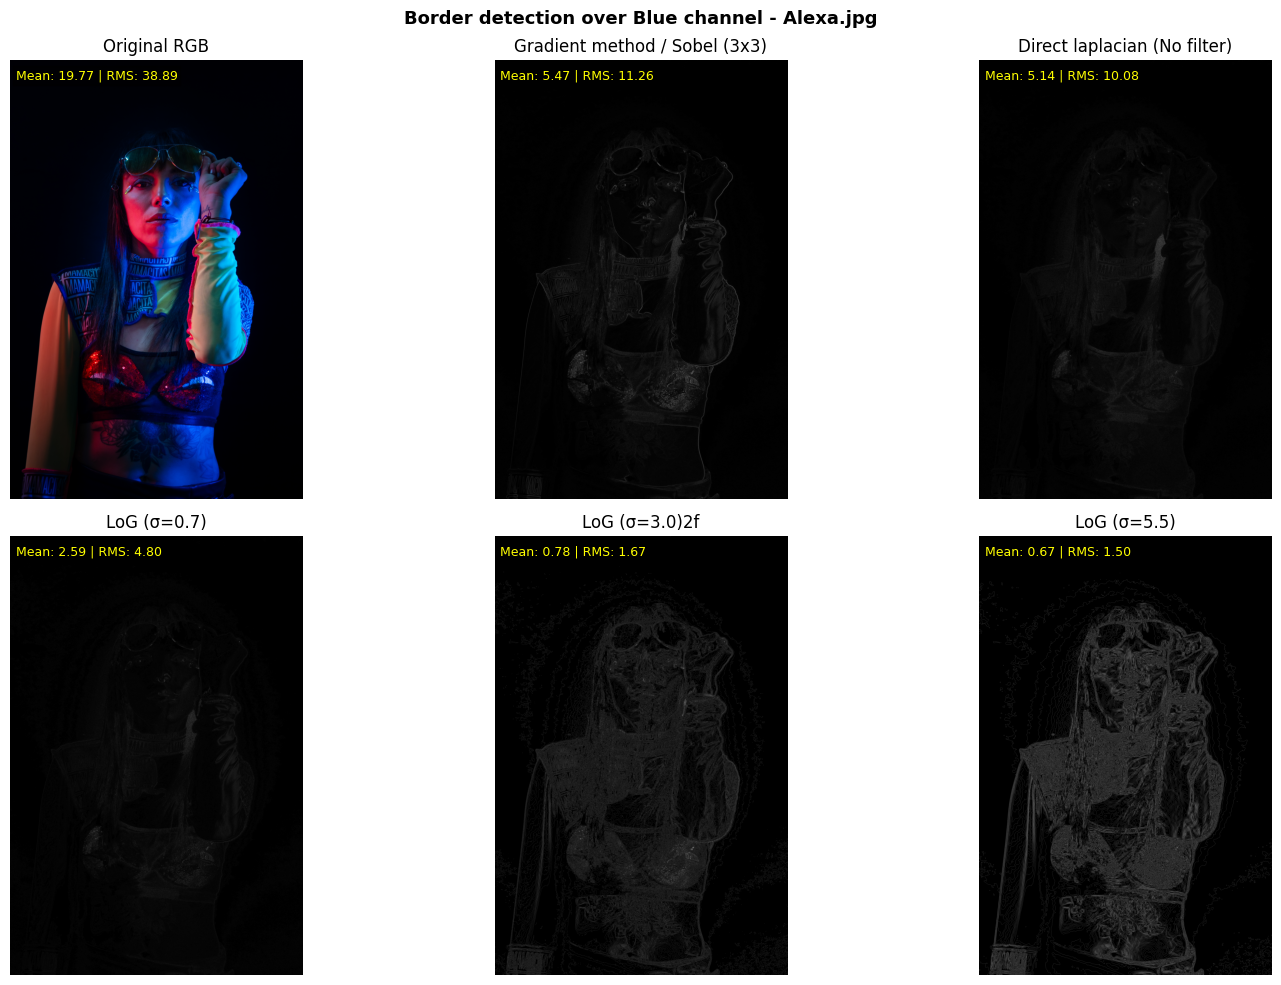

2026-09-09 22:23:43,295 - INFO - 🧹 'CLEAN_LOGS' active. Found 1 previous figure(s) to remove.
2026-09-09 22:23:43,299 - INFO - 🗑️ Deleted previous figure: Perfil2_Practica2_DeteccionBordes__2026-09-09_22-21-23_Fig_Alexa.png
2026-09-09 22:23:58,166 - INFO -   ✅ Comparative panel saved in: Perfil2_Practica2_DeteccionBordes__2026-09-09_22-21-23_Fig_Buenos_Aires.png


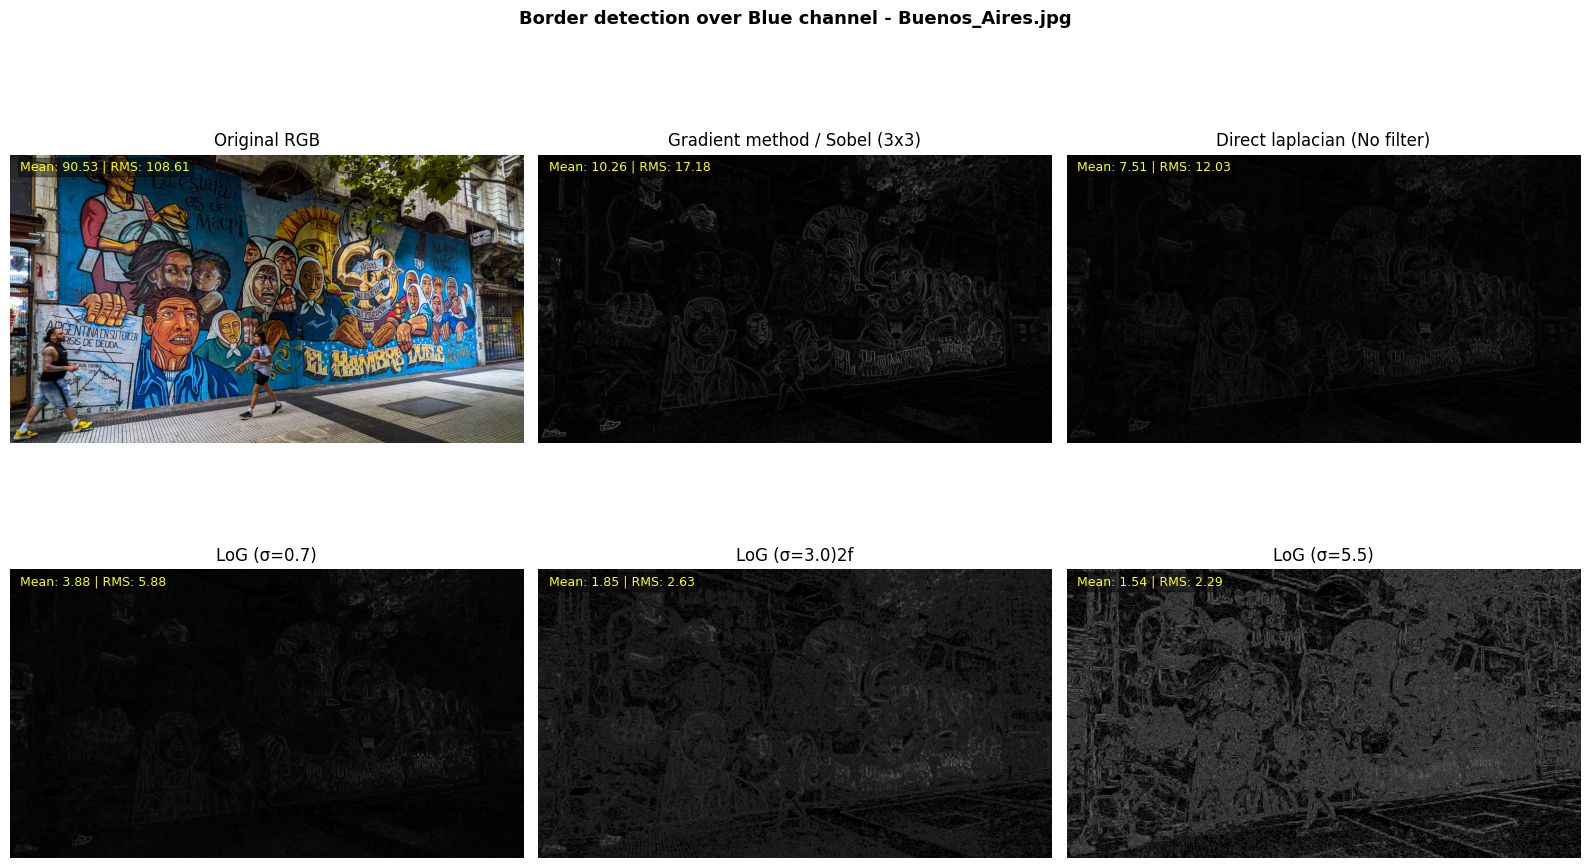

2026-09-09 22:24:10,187 - INFO - 🧹 'CLEAN_LOGS' active. Found 1 previous figure(s) to remove.
2026-09-09 22:24:10,193 - INFO - 🗑️ Deleted previous figure: Perfil2_Practica2_DeteccionBordes__2026-09-09_22-21-23_Fig_Buenos_Aires.png
2026-09-09 22:24:35,291 - INFO -   ✅ Comparative panel saved in: Perfil2_Practica2_DeteccionBordes__2026-09-09_22-21-23_Fig_Piano_Man.png


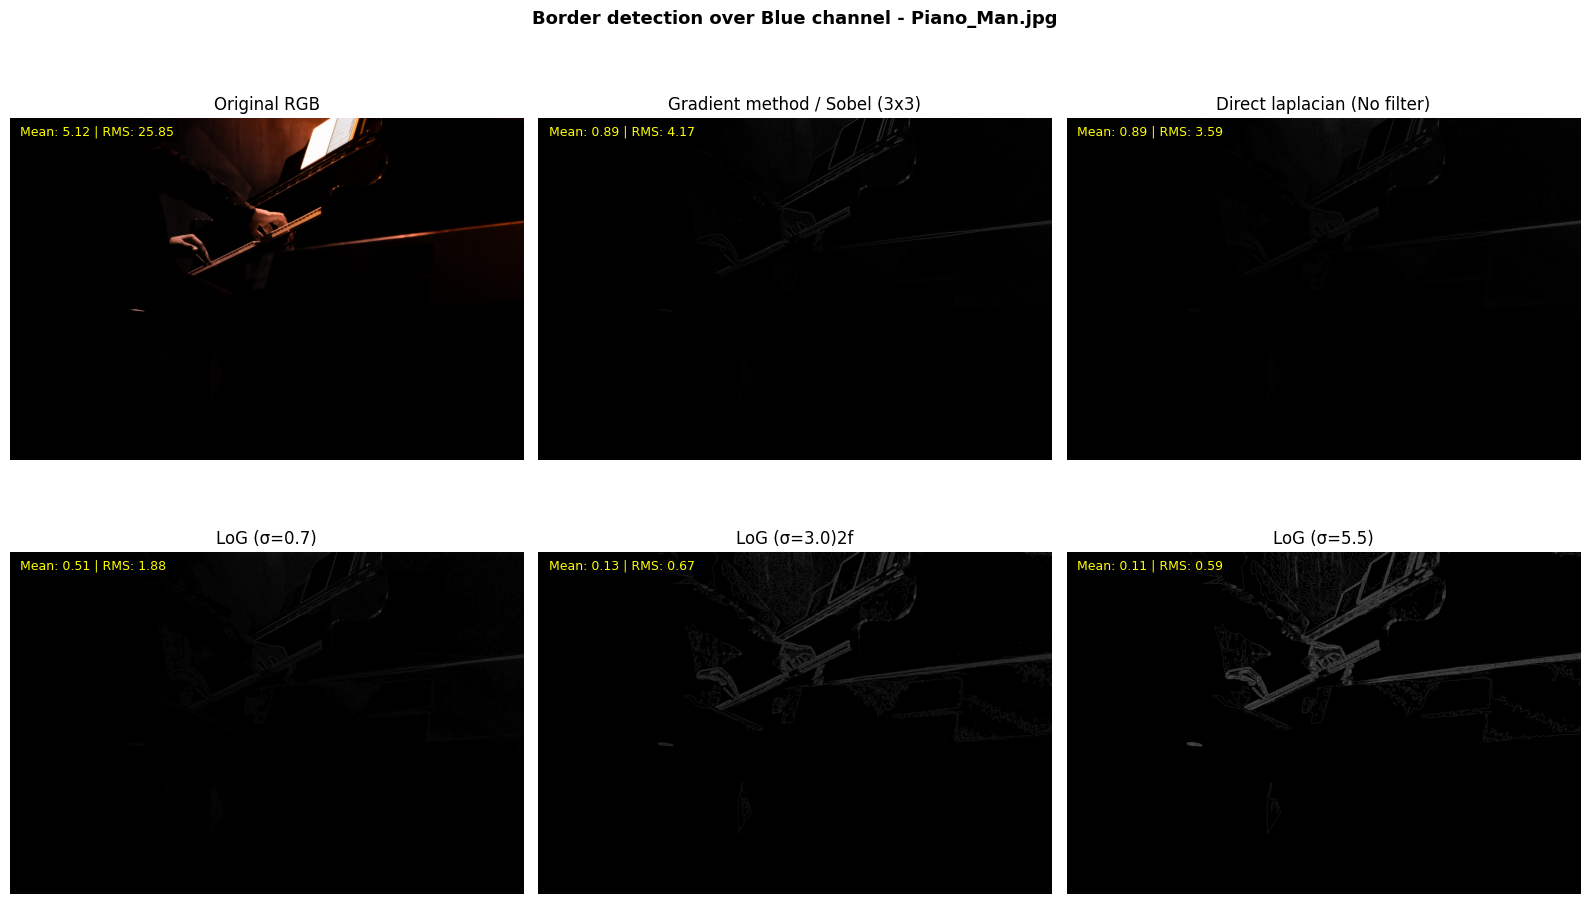

2026-09-09 22:24:56,566 - INFO - 🧹 'CLEAN_LOGS' active. Found 1 previous figure(s) to remove.
2026-09-09 22:24:56,568 - INFO - 🗑️ Deleted previous figure: Perfil2_Practica2_DeteccionBordes__2026-09-09_22-21-23_Fig_Piano_Man.png
2026-09-09 22:25:19,425 - INFO -   ✅ Comparative panel saved in: Perfil2_Practica2_DeteccionBordes__2026-09-09_22-21-23_Fig_Tatto_Studio.png


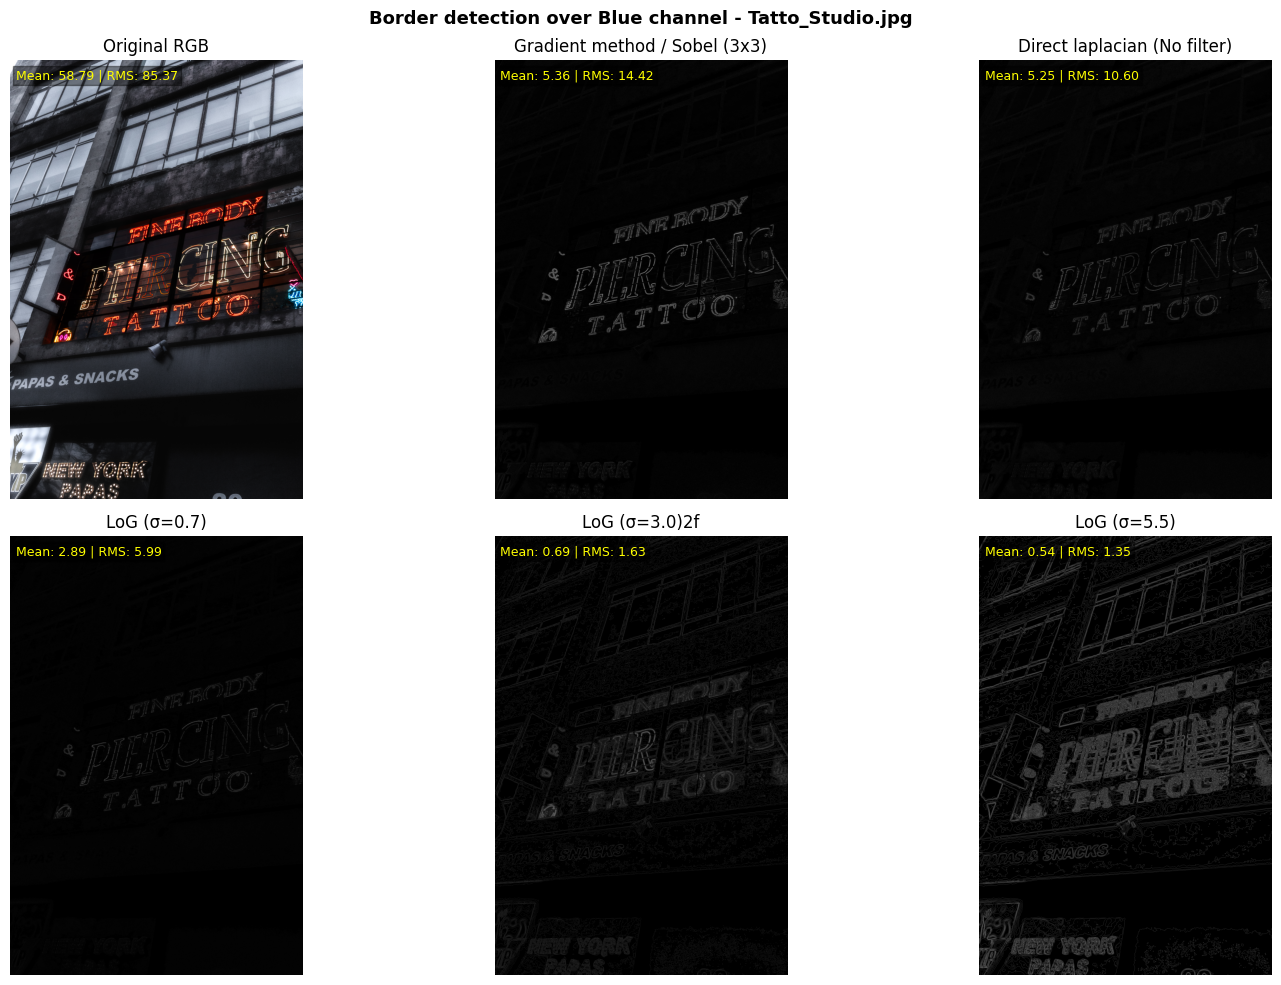

2026-09-09 22:25:39,338 - INFO - 🧹 'CLEAN_LOGS' active. Found 1 previous figure(s) to remove.
2026-09-09 22:25:39,343 - INFO - 🗑️ Deleted previous figure: Perfil2_Practica2_DeteccionBordes__2026-09-09_22-21-23_Fig_Tatto_Studio.png
2026-09-09 22:26:13,804 - INFO -   ✅ Comparative panel saved in: Perfil2_Practica2_DeteccionBordes__2026-09-09_22-21-23_Fig_Ushuaia.png


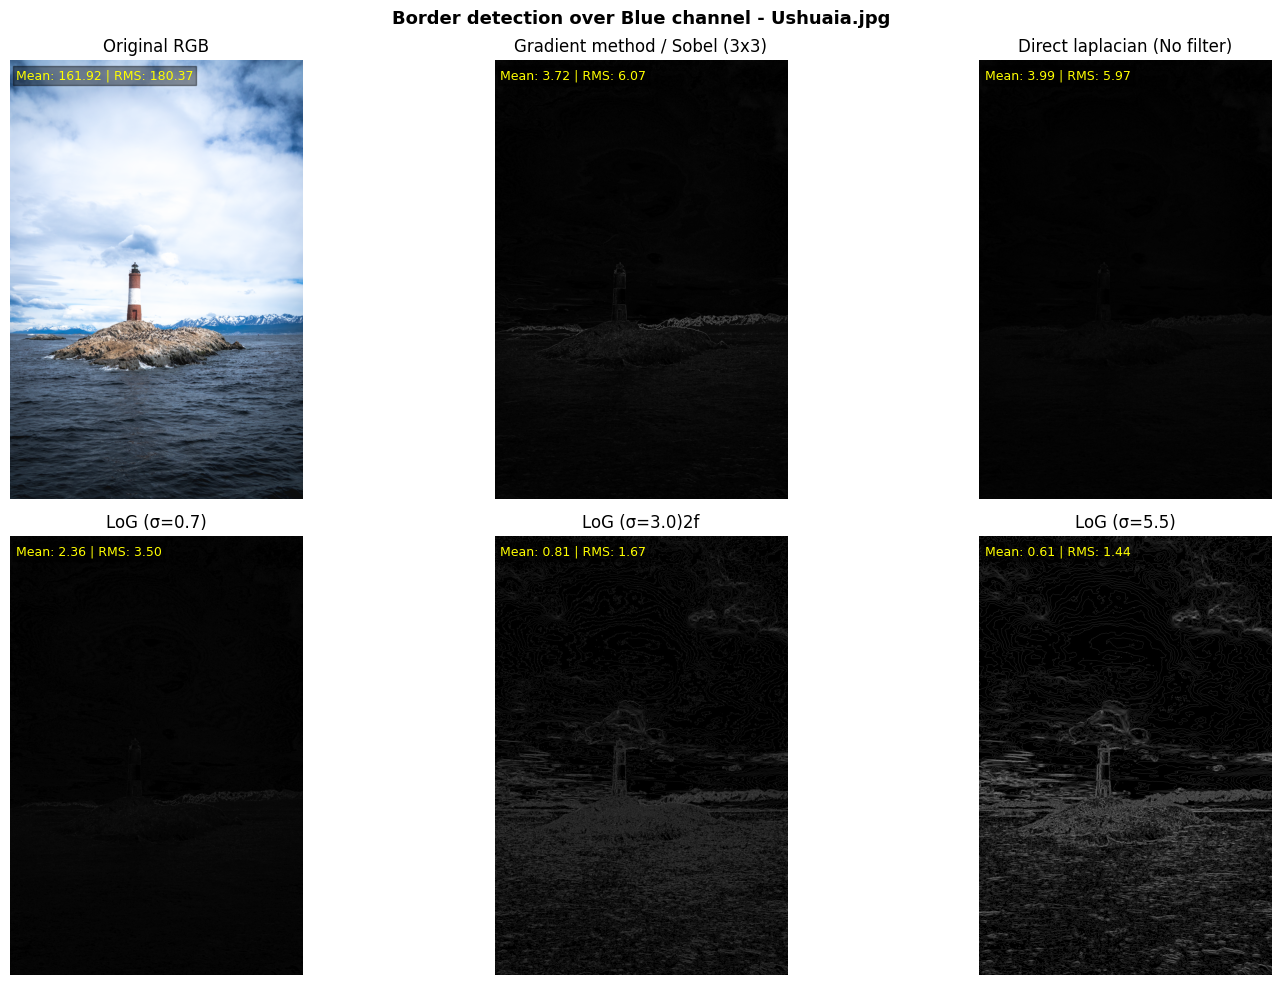

2026-09-09 22:26:34,527 - INFO - ---- SECTION 4: Generating Visual Comparisons (END) ----




In [11]:
logger.info("------- SECTION 4: Generating Visual Comparisons -------")

try:
    for idx, item in enumerate(dataset, 1):
        filename = item["filename"]
        rgb_img = item["rgb"]
        lab_img = rgb_to_lab(rgb_img)

        # 1. Gradiente Sobel
        blue_map, grad_mag, _, _, _ = apply_blue_gradient(lab_img, ksize=3)

        # 2. Laplaciano directo
        _, _, lap_direct_mag, _ = apply_blue_laplacian(lab_img, ksize=3, use_log=False)

        # 3. LoG en 3 escalas
        _, _, log_1, _ = apply_blue_laplacian(lab_img, ksize=3, use_log=True, sigma=SIGMA[1])
        _, _, log_2, _ = apply_blue_laplacian(lab_img, ksize=3, use_log=True, sigma=SIGMA[3])
        _, _, log_3, _ = apply_blue_laplacian(lab_img, ksize=3, use_log=True, sigma=SIGMA[4])

        # Construcción del panel 2x3
        fig, axes = plt.subplots(2, 3, figsize=(16, 10))
        fig.suptitle(f"Border detection over Blue channel - {filename}", fontsize=13, fontweight="bold")

        # Fila 1
        axes[0, 0].imshow(rgb_img)
        axes[0, 0].set_title("Original RGB")
        axes[0, 0].axis("off")
        # Add Mean/RMS for Original (computed on grayscale)
        orig_gray = cv2.cvtColor(rgb_img, cv2.COLOR_RGB2GRAY)
        orig_mean = float(orig_gray.mean())
        orig_rms = float(np.sqrt(np.mean(orig_gray.astype(np.float64) ** 2)))
        axes[0, 0].text(
            0.02, 0.98, f"Mean: {orig_mean:.2f} | RMS: {orig_rms:.2f}",
            color="yellow", fontsize=9, ha="left", va="top",
            transform=axes[0, 0].transAxes, bbox=dict(fc="black", alpha=0.4, pad=2)
        )

        axes[0, 1].imshow(grad_mag, cmap="gray")
        axes[0, 1].set_title(f"Gradient method / Sobel (3x3)")
        axes[0, 1].axis("off")
        # Add Mean/RMS overlay
        grad_mean = float(grad_mag.mean())
        grad_rms = float(np.sqrt(np.mean(grad_mag.astype(np.float64) ** 2)))
        axes[0, 1].text(
            0.02, 0.98, f"Mean: {grad_mean:.2f} | RMS: {grad_rms:.2f}",
            color="yellow", fontsize=9, ha="left", va="top",
            transform=axes[0, 1].transAxes, bbox=dict(fc="black", alpha=0.4, pad=2)
        )

        axes[0, 2].imshow(lap_direct_mag, cmap="gray")
        axes[0, 2].set_title(f"Direct laplacian (No filter)")
        axes[0, 2].axis("off")
        # Add Mean/RMS overlay
        lap_dir_mean = float(lap_direct_mag.mean())
        lap_dir_rms = float(np.sqrt(np.mean(lap_direct_mag.astype(np.float64) ** 2)))
        axes[0, 2].text(
            0.02, 0.98, f"Mean: {lap_dir_mean:.2f} | RMS: {lap_dir_rms:.2f}",
            color="yellow", fontsize=9, ha="left", va="top",
            transform=axes[0, 2].transAxes, bbox=dict(fc="black", alpha=0.4, pad=2)
        )

        # Fila 2: LoG multiescala
        axes[1, 0].imshow(log_1, cmap="gray")
        axes[1, 0].set_title(f"LoG (σ={SIGMA[1]})")
        axes[1, 0].axis("off")
        log1_mean = float(log_1.mean())
        log1_rms = float(np.sqrt(np.mean(log_1.astype(np.float64) ** 2)))
        axes[1, 0].text(
            0.02, 0.98, f"Mean: {log1_mean:.2f} | RMS: {log1_rms:.2f}",
            color="yellow", fontsize=9, ha="left", va="top",
            transform=axes[1, 0].transAxes, bbox=dict(fc="black", alpha=0.4, pad=2)
        )

        axes[1, 1].imshow(log_2, cmap="gray")
        axes[1, 1].set_title(f"LoG (σ={SIGMA[3]})2f")
        axes[1, 1].axis("off")
        log2_mean = float(log_2.mean())
        log2_rms = float(np.sqrt(np.mean(log_2.astype(np.float64) ** 2)))
        axes[1, 1].text(
            0.02, 0.98, f"Mean: {log2_mean:.2f} | RMS: {log2_rms:.2f}",
            color="yellow", fontsize=9, ha="left", va="top",
            transform=axes[1, 1].transAxes, bbox=dict(fc="black", alpha=0.4, pad=2)
        )

        axes[1, 2].imshow(log_3, cmap="gray")
        axes[1, 2].set_title(f"LoG (σ={SIGMA[4]})")
        axes[1, 2].axis("off")
        log3_mean = float(log_3.mean())
        log3_rms = float(np.sqrt(np.mean(log_3.astype(np.float64) ** 2)))
        axes[1, 2].text(
            0.02, 0.98, f"Mean: {log3_mean:.2f} | RMS: {log3_rms:.2f}",
            color="yellow", fontsize=9, ha="left", va="top",
            transform=axes[1, 2].transAxes, bbox=dict(fc="black", alpha=0.4, pad=2)
        )

        plt.tight_layout()

        if CLEAN_LOGS and output_dir.exists():
            fig_pattern = f"{SCRIPT_PREFIX}__*_Fig_*.png"
            old_figs = sorted(list(output_dir.glob(fig_pattern)))
            if old_figs:
                logger.info(f"🧹 'CLEAN_LOGS' active. Found {len(old_figs)} previous figure(s) to remove.")
                for old_fig in old_figs:
                    try:
                        old_fig.unlink()
                        logger.info(f"🗑️ Deleted previous figure: {old_fig.name}")
                    except Exception as del_err:
                        logger.warning(f"⚠️ Could not delete {old_fig.name}: {del_err}")
            else:
                logger.info("ℹ️ No previous figure files found for purging.")


        if SAVE_IMAGES:
            base_stem = Path(filename).stem
            chart_path = output_dir / f"{SCRIPT_PREFIX}__{DATE_STR}_Fig_{base_stem}.png"
            plt.savefig(chart_path, dpi=300, bbox_inches="tight")
            logger.info(f"  ✅ Comparative panel saved in: {chart_path.name}")

        plt.show()
        plt.close(fig)

    logger.info("---- SECTION 4: Generating Visual Comparisons (END) ----\n\n")

except Exception as e:
    logger.error(f"❌ Error during plot: {trace.format_exc()}\n")


## 3. Results

Practice were adapted to premature detection of diabetes mellitus type 2 to search blue color frontiers. In order to perform all calculations, it's needed a conversion to Lab space and invert the channel in order to make the blue spectre more brigther in a grey isolated channel. After this conversion, blue border detection was made successfully via gradient, laplacian or LoG. Gradient method got basic results, best than LoG with a low SIGMA and direct laplacian. This method was enough in images with low contrast like `Tatto_Studio.jpg`, `Buenos_Aires.jpg` or `Piano_Man.jpg`. LoG with SIGMA 3.0 seems to be the best option for the most images, except on the ones with much noise of blue color (many tones in the same area).

---

| Imagen | Características del Espectro Azul | Método Más Efectivo |
| :--- | :--- | :---: |
| **`Alexa.jpg`** | Neon and puntual lights, soft transitions between blue, red and yellow, high contrast against the background  | **LoG ($\sigma = 1.5$)** | 
| **`Tatto_Studio.jpg`** | Natural and dark spectre light, many borders in the drak spectrum. Neon leters high contrasted in red spectred | **Gradiente Sobel ($3 \times 3$)** | 
| **`Buenos_Aires.jpg`** | Urban photography, natural and bright light. Many tones of blue in the same area, complex contrast | **LoG ($\sigma = 0.7 - 1.5$)** | 
| **`Ushuaia.jpg`** | Great portions of blue tones, but contrast is low, the blue tones are faded by the water waves and clouds in the sky. great point of contrast in the middle of the focus | **LoG ($\sigma = 3.0$)** | 
| **`Piano_Man.jpg`** | Low key photography with no visible blue tones, the only borders are shown in the warm spectre (red,yellow). Not many contrast in the image| **LoG ($\sigma = 1.5$)** | 
